In [100]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

path_top = "ELP_SURFACEATTACHED/VPGIG70/top.pdb"
path_tra = "ELP_SURFACEATTACHED/VPGIG70/VPGIG70.dcd"
u = mda.Universe(path_top, path_tra, in_memory=True)

def get_pos_of_resn(res_n):
    positions = []

    for ts in u.trajectory:
        last_res = u.residues[res_n].atoms.select_atoms("name CA")
        positions.append(last_res.positions[0])

    return np.array(positions)

/Users/boraciner/Developer/ELP-Simulations/.venv/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


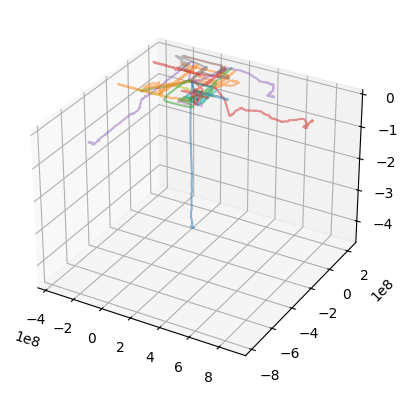

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')

for i in range(0, 300, 20):
    positions = get_pos_of_resn(i)

    ax.plot3D(positions[:, 0], positions[:, 1], positions[:, 2], alpha=.5, fmt="o-")

# ax.axes.set_xlim3d([0, 500])
# ax.axes.set_ylim3d([0, 500])
# ax.axes.set_zlim3d([0, 500])

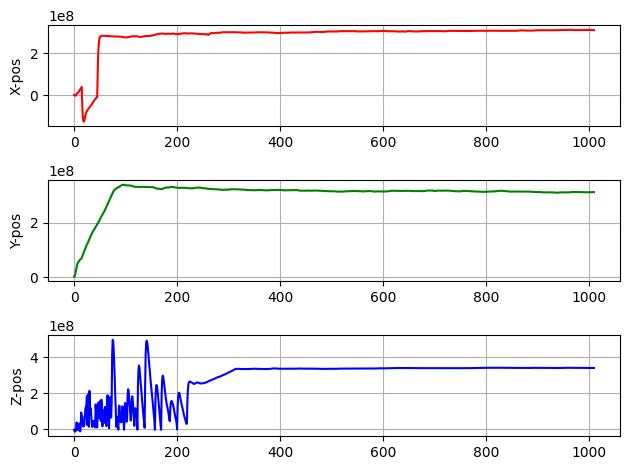

In [103]:
positions = get_pos_of_resn(-1)

plt.figure()

colors = ["red", "green", "blue"]
coords = ["X", "Y", "Z"]
for i in range(3):
    plt.subplot(311 + i)
    plt.plot(positions[:, i], color=colors[i])
    plt.ylabel(f"{coords[i]}-pos")
    # plt.ylim([0, 500])
    plt.grid()

plt.tight_layout()

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_msd(csv_path):
    df = pd.read_csv(csv_path)
    df = df.sort_values(by=['TID', 't [sec]'])
    
    # Determine the time interval (delta_t) from the first track
    first_track = df[df['TID'] == df['TID'].iloc[0]]
    delta_t = first_track['t [sec]'].diff().iloc[1] 

    max_len = df.groupby('TID').size().max()
    msd_values = []
    time_lags = []

    for tau in range(1, max_len):
        sq_displacements = []
        for tid in df['TID'].unique():
            track = df[df['TID'] == tid]
            coords = track[['x [µm]', 'y [µm]']].values
            
            if len(coords) > tau:
                disp = coords[tau:] - coords[:-tau]
                sq_disp = np.sum(disp**2, axis=1)
                sq_displacements.extend(sq_disp)
        
        if sq_displacements:
            msd_values.append(np.mean(sq_displacements))
            time_lags.append(tau * delta_t) # Convert lag to seconds

    # Plotting

    return time_lags, msd_values

time_lags, msd_values = plot_msd('MTrackJ_ Points.csv')

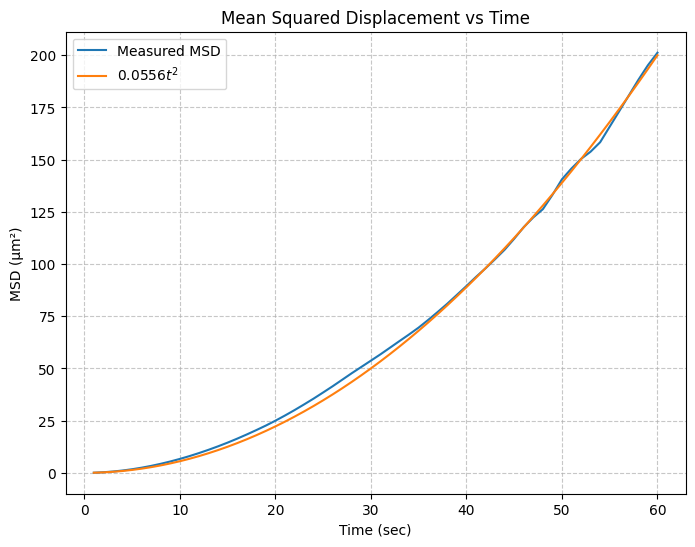

In [99]:
import numpy as np
from scipy.stats import linregress

# Assuming 'time_lags' and 'msd_values' are arrays from the previous step
# We fit the first 25% of the data points to ensure we are in the linear regime
fit_range = int(len(time_lags) * 0.25)
x = time_lags[:fit_range]
y = msd_values[:fit_range]

slope, intercept, r_value, p_value, std_err = linregress(x, y)

plt.figure(figsize=(8, 6))
plt.plot(time_lags, msd_values, '-', label='Measured MSD')
plt.plot(time_lags, np.array(time_lags) ** 2 * 1 / 18, '-', label='$0.0556t^2$')
plt.legend()
plt.xlabel('Time (sec)')
plt.ylabel('MSD (µm²)')
plt.title('Mean Squared Displacement vs Time')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()